# Long-duration Category 3–5 best-track statistics

This notebook scans every Atlantic (`bal`), central North Pacific (`bcp`), eastern North Pacific (`bep`), and western North Pacific (`bwp`) B-deck file. For each storm it calls `find_bdeck_threshold_period` and reports the first closed threshold interval whose duration is strictly longer than the requested minimum.

The default `VMAX > 95 kt` condition represents Category 3–5 intensity because Category 3 begins at 96 kt and the threshold function uses a strict comparison. The returned interval is `[start_cycle, end_cycle)`: the ending B-deck record is the first non-qualifying record and is excluded from the VMAX and PMIN extrema. Open-ended intervals (`end_cycle is None`) are excluded because their complete duration is unknown.

In [1]:
from __future__ import annotations

import csv
import re
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

try:
    from src import mod_abdeck as abdeck
    from src import mod_verification as verif
except ModuleNotFoundError as exc:
    if exc.name != "src":
        raise
    import mod_abdeck as abdeck
    import mod_verification as verif

## Inputs

Change these values to scan for another metric threshold or minimum duration. The duration comparison is strict, so `minimum_duration_hours = 72` retains intervals longer than 72 hours, not intervals equal to 72 hours.

In [2]:
threshold_metric = "VMAX"
threshold_value = 95  # find_bdeck_threshold_period uses VMAX > threshold.
minimum_duration_hours = 72

In [3]:
BDECK_FILENAME = re.compile(r"^b(al|cp|ep|wp)(\d{2})(\d{4})\.dat$")
BASIN_ID_BY_CODE = {"al": "L", "cp": "C", "ep": "E", "wp": "W"}
BASIN_NAME_BY_ID = {
    "L": "Atlantic",
    "C": "Central Pacific",
    "E": "Eastern Pacific",
    "W": "Western Pacific",
}


def read_storm_name(path: Path) -> str:
    """Return the last non-empty storm name on a BEST record."""
    storm_name = "UNKNOWN"
    with path.open("r", encoding="utf-8", errors="replace", newline="") as handle:
        for fields in csv.reader(handle):
            if len(fields) > 27 and fields[4].strip().upper() == "BEST":
                candidate = fields[27].strip().upper()
                if candidate:
                    storm_name = candidate
    return storm_name


def values_in_period(
    records: Dict[datetime, float],
    start_time: datetime,
    end_time: datetime,
) -> List[float]:
    """Return values in the half-open interval [start_time, end_time)."""
    return [
        value
        for cycle, value in records.items()
        if start_time <= cycle < end_time
    ]


def display_value(value: Optional[float]) -> Any:
    if value is None:
        return "NA"
    return int(value) if float(value).is_integer() else round(float(value), 2)


def print_table(rows: Sequence[Dict[str, Any]], columns: Sequence[str]) -> None:
    """Print dictionaries as a fixed-width table with exactly nine columns."""
    text_rows = [[str(row[column]) for column in columns] for row in rows]
    widths = [
        max([len(column)] + [len(row[index]) for row in text_rows])
        for index, column in enumerate(columns)
    ]
    header = " | ".join(column.ljust(width) for column, width in zip(columns, widths))
    separator = "-+-".join("-" * width for width in widths)
    print(header)
    print(separator)
    for row in text_rows:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))

## Scan all B-decks

In [4]:
results: List[Dict[str, Any]] = []
files_scanned = 0
open_intervals_skipped = 0

for bdeck_path in sorted(verif.BDECK_DIR.glob("b*.dat")):
    match = BDECK_FILENAME.fullmatch(bdeck_path.name)
    if match is None:
        continue

    basin_code, storm_number, year = match.groups()
    basin_id = BASIN_ID_BY_CODE[basin_code]
    storm_id = f"{storm_number}{basin_id}"
    files_scanned += 1

    start_cycle, end_cycle = abdeck.find_bdeck_threshold_period(
        storm_id=storm_id,
        year=year,
        metric=threshold_metric,
        threshold=threshold_value,
        bdeck_dir=verif.BDECK_DIR,
    )
    if start_cycle is None:
        continue
    if end_cycle is None:
        open_intervals_skipped += 1
        continue

    start_time = datetime.strptime(start_cycle, "%Y%m%d%H")
    end_time = datetime.strptime(end_cycle, "%Y%m%d%H")
    duration_hours = int((end_time - start_time).total_seconds() / 3600)
    if duration_hours <= minimum_duration_hours:
        continue

    vmax_values = values_in_period(
        abdeck._read_bdeck_metric(bdeck_path, "VMAX"), start_time, end_time
    )
    pmin_values = values_in_period(
        abdeck._read_bdeck_metric(bdeck_path, "PMIN"), start_time, end_time
    )
    results.append(
        {
            "storm name": read_storm_name(bdeck_path),
            "storm id": storm_id,
            "basin": BASIN_NAME_BY_ID[basin_id],
            "year": year,
            "start_cycle": start_cycle,
            "end_cycle": end_cycle,
            "duration (h)": duration_hours,
            "max VMAX (kt)": display_value(max(vmax_values) if vmax_values else None),
            "min PMIN (hPa)": display_value(min(pmin_values) if pmin_values else None),
        }
    )

results.sort(key=lambda row: (row["year"], row["basin"], row["storm id"]))

In [5]:
columns = [
    "storm name",
    "storm id",
    "basin",
    "year",
    "start_cycle",
    "end_cycle",
    "duration (h)",
    "max VMAX (kt)",
    "min PMIN (hPa)",
]
print_table(results, columns)
print()
print(f"B-deck files scanned: {files_scanned}")
print(f"Qualifying closed intervals longer than {minimum_duration_hours} h: {len(results)}")
print(f"Open-ended threshold intervals skipped: {open_intervals_skipped}")

storm name | storm id | basin           | year | start_cycle | end_cycle  | duration (h) | max VMAX (kt) | min PMIN (hPa)
-----------+----------+-----------------+------+-------------+------------+--------------+---------------+---------------
ANDREW     | 04L      | Atlantic        | 1992 | 1992082300  | 1992082612 | 84           | 150           | 922           
DEAN       | 04L      | Atlantic        | 2007 | 2007081718  | 2007082118 | 96           | 150           | 905           
FLOSSIE    | 09E      | Eastern Pacific | 2007 | 2007081106  | 2007081412 | 78           | 120           | 949           
EARL       | 07L      | Atlantic        | 2010 | 2010083012  | 2010090300 | 84           | 125           | 927           
IGOR       | 11L      | Atlantic        | 2010 | 2010091218  | 2010091718 | 120          | 135           | 924           
HILARY     | 09E      | Eastern Pacific | 2011 | 2011092300  | 2011092718 | 114          | 125           | 942           
MUIFA      | 11W      | 

## Annual mean duration and TC count

The line uses the left y-axis and shows the mean qualifying duration for each year. The bars use the right y-axis and show the number of qualifying TCs. Calendar years with no qualifying storms are retained with a zero-height bar and a gap in the duration line.

In [6]:
def plot_annual_duration_and_counts(
    rows: Sequence[Dict[str, Any]],
    *,
    figsize: tuple[float, float] = (14, 6),
):
    """Plot annual mean duration and qualifying-TC count on twin axes."""
    if not rows:
        raise ValueError("At least one qualifying storm is required.")

    durations_by_year: Dict[int, List[float]] = {}
    for row in rows:
        year = int(row["year"])
        duration = float(row["duration (h)"])
        durations_by_year.setdefault(year, []).append(duration)

    years = list(range(min(durations_by_year), max(durations_by_year) + 1))
    mean_durations = [
        sum(durations_by_year[year]) / len(durations_by_year[year])
        if year in durations_by_year
        else float("nan")
        for year in years
    ]
    tc_counts = [len(durations_by_year.get(year, [])) for year in years]

    fig, duration_axis = plt.subplots(figsize=figsize)
    count_axis = duration_axis.twinx()

    count_axis.bar(
        years,
        tc_counts,
        width=0.8,
        color="tab:orange",
        alpha=0.3,
        label="TC count",
        zorder=1,
    )
    duration_axis.plot(
        years,
        mean_durations,
        color="tab:blue",
        marker="o",
        linewidth=2,
        label="Mean duration",
        zorder=2,
    )

    duration_axis.set_xlabel("Year")
    duration_axis.set_ylabel("Average qualifying duration (h)", color="tab:blue")
    count_axis.set_ylabel("Number of TCs", color="tab:orange")
    duration_axis.tick_params(axis="y", labelcolor="tab:blue")
    count_axis.tick_params(axis="y", labelcolor="tab:orange")
    count_axis.yaxis.set_major_locator(MaxNLocator(integer=True))
    duration_axis.set_xticks(years)
    duration_axis.set_xticklabels(years, rotation=90, fontsize=8)
    duration_axis.set_xlim(years[0] - 0.75, years[-1] + 0.75)
    duration_axis.grid(axis="y", alpha=0.3)
    duration_axis.set_title("Annual Category 3–5 duration and TC count")

    handles_left, labels_left = duration_axis.get_legend_handles_labels()
    handles_right, labels_right = count_axis.get_legend_handles_labels()
    duration_axis.legend(
        handles_left + handles_right,
        labels_left + labels_right,
        loc="upper left",
    )
    fig.tight_layout()
    return fig, (duration_axis, count_axis)

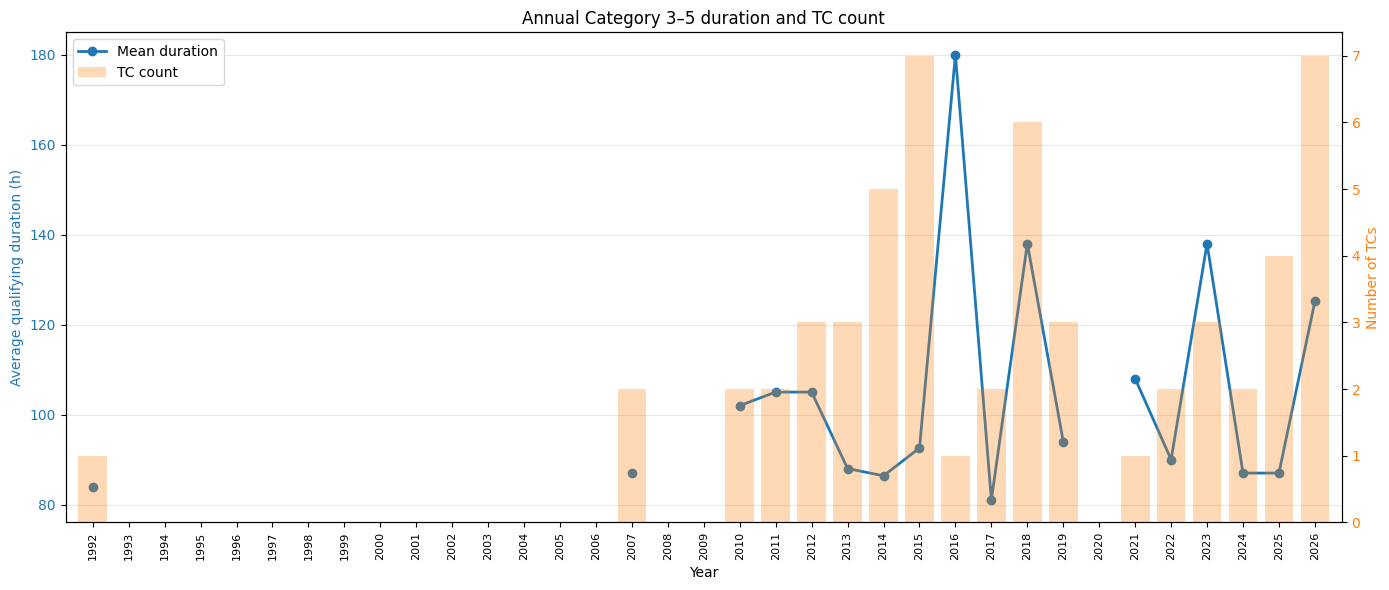

In [7]:
annual_fig, annual_axes = plot_annual_duration_and_counts(results)